Implementation of Numerical Algorithms based on Mark Newman's Computation Physics

In [ ]:
#integrating a function(사다리꼴 방법)

def f(x):
  return x**4-2*x+1

N=1001
a=0.0
b=2.0
h=(b-a)/N

s=0.5*f(a)+0.5*f(b)
for k in range(1,N):
  s+=f(a+k*h)

print(h*s)

4.400010645364226


In [ ]:
#simpson rule(심슨방법)
def f(x):
  return x**4-2*x+1

N=1000
a=0.0
b=2.0
h=(b-a)/N

s=f(a)+f(b)
p1=0
p2=0
for k in range(1,int(N/2+1)):
  p1=p1+f(a+(2*k-1)*h)
for i in range(1,int(N/2)):
  p2=p2+f(a+2*i*h)
print((1/3)*h*(s+4*p1+2*p2))

4.400000000004267


In [ ]:
# 적분할 함수 정의
def f(x):
  return x**4 - 2*x + 1

# 적분 변수 설정
a = 0.0
b = 2.0
N = 10000000 # N은 짝수여야 합니다.

# simpson_rule 함수를 사용하여 적분 값 계산
integral_result = simpson_rule(f, a, b, N)
print(f"심슨 규칙으로 계산된 적분 값: {integral_result}")

In [ ]:
#quad
from scipy.integrate import quad
x=lambda x:x**4 - 2*x + 1
res,err=quad(x,0,2)
print(res,err)

4.3999999999999995 5.003996496050337e-14


In [ ]:
def f(x):
  return (1-x**2)**0.5

N=100000
a=-1
b=1
h=(b-a)/N

s=0.5*f(a)+0.5*f(b)
for k in range(1,N):
  s+=f(a+k*h)

print(h*s)


1.5707962742034143


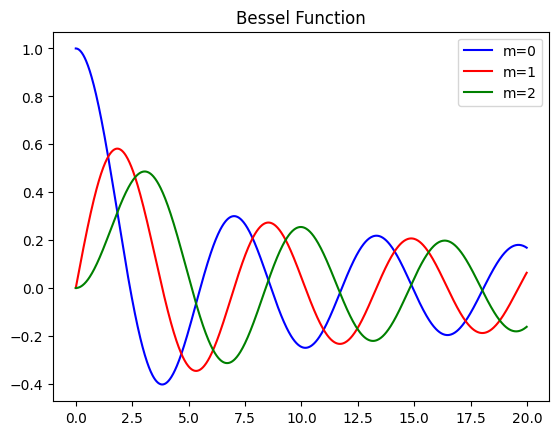

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#베셀함수
def J(m,x):
  def f(theta):
    return np.cos(m*theta-x*np.sin(theta))
  a=0
  b=np.pi
  N=100000
  h=(b-a)/N
  s=f(a)+f(b)
  s1=0
  s2=0
  for i in range(1,int(N/2)+1):
    s1+=f(a+(2*i-1)*h)
  for k in range(1,int(N/2-1)+1):
    s2+=f(a+(2*k*h))
  total=1/3*h*(s+4*s1+2*s2)
  return 1/np.pi*(total)

a=0
b=20
N=1000
h=(b-a)/N

x=np.arange(0,20,h)
j0=J(0,x)
j1=J(1,x)
j2=J(2,x)
j3=J(3,x)
plt.plot(x,j0,color='blue',label='m=0')
plt.plot(x,j1,color='red',label='m=1')
plt.plot(x,j2,color='green',label='m=2')
plt.title('Bessel Function')
plt.legend()
plt.show()









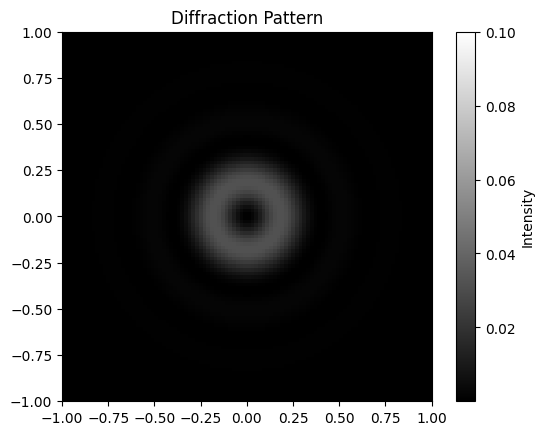

In [ ]:
#심슨 적분을 통한 빛의 원형 회절 구현
import numpy as np
import matplotlib.pyplot as plt

def J(m,x): #베셀 함수
  def f(theta):
    return np.cos(m*theta-x*np.sin(theta))
  a=0
  b=np.pi
  N=100000
  h=(b-a)/N
  s=f(a)+f(b)
  s1=0
  s2=0
  for i in range(1,int(N/2)+1):
    s1+=f(a+(2*i-1)*h)
  for k in range(1,int(N/2-1)+1):
    s2+=f(a+(2*k*h))
  total=1/3*h*(s+4*s1+2*s2)
  return 1/np.pi*(total)

a=0
b=20
N=1000
h=(b-a)/N

wavelength=0.5
k=(2*np.pi)/wavelength

X,Y=np.meshgrid(np.linspace(-1,1,100),np.linspace(-1,1,100))
r=np.sqrt(X**2+Y**2)

# 0으로 나누기 문제 처리: k*r이 0인 경우를 아주 작은 상수 값으로 대체
k_r = k * r
k_r[k_r == 0] = np.finfo(float).eps # 플로팅 포인트 수의 가장 작은 양수 값

I=(J(2,k_r)/k_r)**2
plt.imshow(I,vmax=0.1, origin='lower', extent=[-1, 1, -1, 1], cmap='gray')
plt.colorbar(label='Intensity')
plt.title('Diffraction Pattern')
plt.show()

In [ ]:

import numpy as np
def f(x):
  return np.sqrt(1-x**2)

def I_trapz(f,a,b,n):
  x=np.linspace(a,b,n+1)
  sum=0.5*f(a)+0.5*f(b)
  sum+=np.sum(f(x[1:-1]))
  return sum*(x[1]-x[0])

# 적분 구간을 일반적으로 작은 값에서 큰 값으로 수정 (-1에서 1)
a = -1.0
b = 1.0
N = 1000
integral_result = I_trapz(f, a, b, N)
print(f"사다리꼴 규칙으로 계산된 적분 값: {integral_result}")

사다리꼴 규칙으로 계산된 적분 값: 1.5707437385010716


In [ ]:
#errors in integrals
def f(x):
  return x**4-2*x+1

N1=10
N2=20
a=0.0
b=2.0
h1=(b-a)/N1
h2=(b-a)/N2

s1=0.5*f(a)+0.5*f(b)
s2=0.5*f(a)+0.5*f(b)
for i in range(1,N1):
  s1+=f(a+i*h1)
for j in range(1,N2):
  s2+=f(a+j*h2)

print((1/3)*(h2*s2)-(h1*s1))
print(h2*s2)
print(h1*s1)



-3.031006666666667
4.426660000000001
4.50656


In [ ]:
#romberg integration
import numpy as np

def romberg(f, a, b, max_steps=5):
  R=np.zeros((max_steps,max_steps))
  h=b-a
  R[0][0]=0.5*h*(f(a)+f(b))
  for i in range(1,max_steps):
    h/=2.0
    num_points=2**i
    sum_f=sum(f(a+k*h) for k in range(1,num_points,2))
    R[i][0]=0.5*R[i-1][0]+h*sum_f
    for j in range(1,i+1):
      factor=4**j
      R[i][j]=(factor * R[i][j-1]-R[i-1][j-1]) / (factor-1)
  return R

def my_func(x):
  return x**2
table = romberg(my_func,0,1,max_steps=4)
print("롬베르그 테이블")
print(table)
print(f"\n최종 적분 결과:{table[-1][-1]}")

롬베르그 테이블
[[0.5        0.         0.         0.        ]
 [0.375      0.33333333 0.         0.        ]
 [0.34375    0.33333333 0.33333333 0.        ]
 [0.3359375  0.33333333 0.33333333 0.33333333]]

최종 적분 결과:0.3333333333333333


In [ ]:
import numpy as np
t=[]
I=[]
def func(x):
  return (np.sin(np.sqrt(100*x)))**2

def trapizodial(f,a,b,n):
  s=0.5*func(a)+0.5*func(b)
  h=(b-a)/n
  for j in range(1,n):
    s+=func(a+j*h)
  return h*s
def adaptive_trapizodial(f,a,b,n,tol):
  p=trapizodial(f,a,b,n)
  t.append(p)
  n=2*n
  h=(b-a)/n
  p+=trapizodial(f,a,b,n)
  p=h*p
  t.append(p)
  return p
g=trapizodial(func,0,1,4)
q=adaptive_trapizodial(func,0,1,4,10**(-6))
print(g)
print(q)















0.5122828507233315
0.11441003740019746


Text(0.5, 0, 'Error')

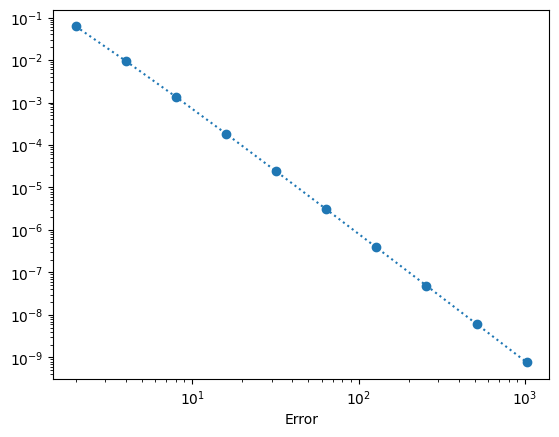

In [ ]:
#가우시안 적분
from scipy.integrate import fixed_quad
import numpy as np
import matplotlib.pyplot as plt
f=lambda x: np.sqrt(1.0-x**2)
g=np.vectorize(lambda i : fixed_quad(f,-1,1,n=2**(i+1))[0])
y=np.fromfunction(g,(10,))
plt.loglog(2**np.arange(1,11),np.abs(y-np.pi*0.5),"o:")
plt.xlabel('N')
plt.xlabel('Error')

In [ ]:
import numpy as np

def f(x):
  return x**4-2*x+1

N=3
a=0.0
b=2.0

x,w=np.polynomial.legendre.leggauss(N) #가중치 계산
xp=0.5*(b-a)*x + 0.5*(b+a)
wp=0.5*(b-a)*w

s=0.0
for k in range(N):
  s+=wp[k]*f(xp[k])

print(s)

4.400000000000001


In [ ]:
#heat capacity of solid
import numpy as np

V=1
p=6.022E28
d=428
k=1.38e-23
t=9000
e=9*V*p*k*((t/d)**3)

a=0
b=d/t

def sfunc(x):
  return (x**4*np.exp(x))/(np.exp(x)-1)**2
N=50
x,w=np.polynomial.legendre.leggauss(N)
xp=0.5*(b-a)*x+0.5*(b+a)
wp=0.5*(b-a)*w

s=0.0
for j in range(N):
  s+=wp[j]*sfunc(xp[j]) # Changed f to sfunc as per the function definition

print(s)

3.5845398812909976e-05


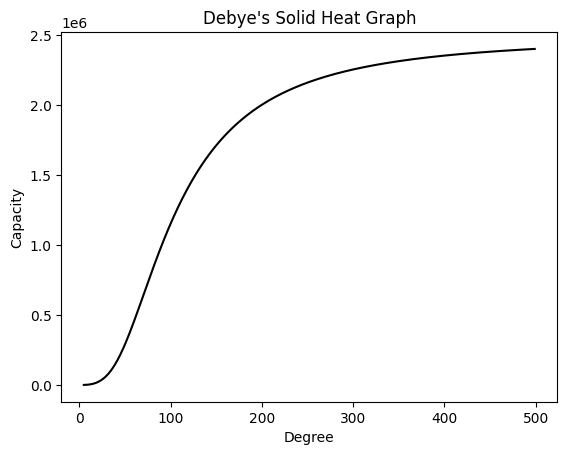

In [ ]:
#Debye's heat capacity of a solid graph-가우시안 적분을 통해 디바이의 열용량 그래프 구현

import numpy as np
import matplotlib.pyplot as plt

debye_value=[]
def debye(T,N):# 디바이 값
  V=1
  p=6.022E28
  d=428
  k=1.38e-23
  h=T/d
  e=9*V*p*k*(h**3)

  a=0
  b=1/h

  def sfunc(x):
    return (x**4*np.exp(x))/((np.exp(x)-1)**2)
  x,w=np.polynomial.legendre.leggauss(N)
  xp=0.5*(b-a)*x+0.5*(b+a) #가우시안 적분
  wp=0.5*(b-a)*w

  s=0.0
  for j in range(N):
    s+=wp[j]*sfunc(xp[j])
  return e*s
g=np.arange(5,500)
for k in g:
  c=debye(k,50)
  debye_value.append(c)
plt.plot(g,debye_value,'k-')
plt.xlabel("Degree") # 온도
plt.ylabel("Capacity") # 열용량
plt.title("Debye's Solid Heat Graph") # 온도에 따른 열용량
plt.show()

In [ ]:
#전방차분,후방차분,중앙차분
import numpy as np
h=[1e-2,1e-4,1e-6,1e-8]
def f(x):
  return np.sin(x)

def forward_diff(x,h):
  y=(f(x+h)-f(x))/h
  return y

def backward_diff(x,h):
  z=(f(x)-f(x-h))/h
  return z

def cent_diff(x,h):
  i=(f(x+h)-f(x-h))/(2*h)
  return i

print(f(1))
for i in range(0,4):
  print(f"전방차분 값:",{float(forward_diff(1,h[i]))},
        "후방차분 값:",{float(backward_diff(1,h[i]))},
        "중앙차분값:",{float(cent_diff(1,h[i]))})




In [ ]:
# Integrating over an infinite range(무한 범위의 적분)
import numpy as np

from numpy import ones,copy,cos,tan,pi,linspace

def gaussxw(N):

    # Initial approximation to roots of the Legendre polynomial
    a = linspace(3,4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))

    # Find roots using Newton's method
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x)
        for k in range(1,N):
            p0,p1 = p1,((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1)*(p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))

    # Calculate the weights
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)

    return x,w

def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a),0.5*(b-a)*w

def f(z):
  return np.exp(-z**2/(1-z)**2)/(1-z)**2

N=50
a=0.0
b=1.0
x,w=gaussxwab(N,a,b)
s=0.0
for k in range(N):
  s+=w[k]*f(x[k])
print(s)

0.8862269254528349


In [ ]:
from numpy import ones,copy,cos,tan,pi,linspace
import numpy as np

def gaussxw(N):

    # Initial approximation to roots of the Legendre polynomial
    a = linspace(3,4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))

    # Find roots using Newton's method
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x)
        for k in range(1,N):
            p0,p1 = p1,((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1)*(p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))

    # Calculate the weights
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)

    return x,w

def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a),0.5*(b-a)*w
k=1.381e-23
T=5000
h=1.054e-34
c=3e+8
d=(k*T)/(4*(np.pi)**2)*h

def f(z):
  # Clip the argument of exp to prevent overflow
  exp_arg = np.clip(z/(1-z), a_min=None, a_max=700) # 700 is a safe upper limit for exp
  return (z**3/(1-z)**5)/(np.exp(exp_arg)-1) #x = (1/1-z**2)로 치환

N=1000
N2=2000
a=0.0
b=1.0
s=0.0
s2=0.0
x,w=gaussxwab(N,a,b)
x2,w2=gaussxwab(N2,a,b)
for i in range(N):
  s+=w[i]*f(x[i])
for j in range(N):
  s2+=w2[j]*f(x2[j])

print(d*s)
print(d*s2)

print(d*s2-d*s)


1.1971616297092718e-54
1.1557187648869847e-54
-4.144286482228708e-56


In [ ]:
from numpy import ones,copy,cos,tan,pi,linspace
import numpy as np

def gaussxw(N):

    # Initial approximation to roots of the Legendre polynomial
    a = linspace(3,4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))

    # Find roots using Newton's method
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x)
        for k in range(1,N):
            p0,p1 = p1,((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1)*(p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))

    # Calculate the weights
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)

    return x,w

def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a),0.5*(b-a)*w
k=1.381e-23
T=5000
h=1.054e-34
c=3e+8
d=(k*T)/(4*(np.pi)**2)*h

def f(z):
  # Clip the argument of exp to prevent overflow
  exp_arg = np.clip(z/(1-z), a_min=None, a_max=700) # 700 is a safe upper limit for exp
  return (z**3/(1-z)**5)/(np.exp(exp_arg)-1)

N=1000
N2=2000
a=0.0
b=1.0
s=0.0
s2=0.0
x,w=gaussxwab(N,a,b)
x2,w2=gaussxwab(N2,a,b)
for i in range(N):
  s+=w[i]*f(x[i])
for j in range(N):
  s2+=w2[j]*f(x2[j])

print(d*s)
print(d*s2)

print(d*s2-d*s)


1.1971616297092718e-54
1.1557187648869847e-54
-4.144286482228708e-56


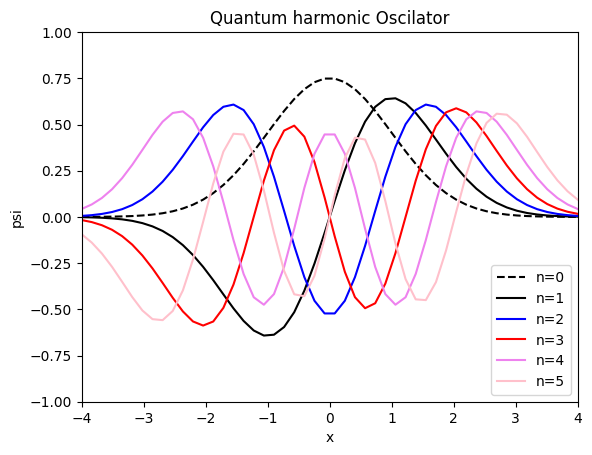

In [ ]:
#the harmonic oscillations
import numpy as np
import math
import matplotlib.pyplot as plt

def gaussxw(N):

    # Initial approximation to roots of the Legendre polynomial
    a = linspace(3,4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))

    # Find roots using Newton's method
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x)
        for k in range(1,N):
            p0,p1 = p1,((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1)*(p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))

    # Calculate the weights
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)

    return x,w

def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a),0.5*(b-a)*w

t=np.linspace(-4,4)

def H(n,x):
  if n==0:
    return 1
  if n==1:
    return 2*x
  if n==2:
    return 4*x**2-2
  if n==3:
    return 8*x**3-12*x
  if n==4:
    return 16*x**4-48*x**2+12
  if n==5:
    return 32*x**5-160*x**3+120*x
def psi(n,x):
  return (1/(np.sqrt(2**n*math.factorial(n)*np.sqrt(np.pi))))*np.exp(-x**2/2)*H(n,x)

p0=psi(0,t)
p1=psi(1,t)
p2=psi(2,t)
p3=psi(3,t)
p4=psi(4,t)
p5=psi(5,t)

plt.plot(t,p0,"k--",label='n=0')
plt.plot(t,p1,"k-",label='n=1')
plt.plot(t,p2,"b-",label='n=2')
plt.plot(t,p3,"r-",label='n=3')
plt.plot(t,p4,color="violet",label='n=4')
plt.plot(t,p5,color="pink",label='n=5')
plt.xlim(-4.0,4.0)
plt.ylim(-1.0,1.0)
plt.xlabel("x")
plt.ylabel("psi")
plt.title("Quantum harmonic Oscilator")
plt.legend()
plt.show()







In [ ]:
#양자 조화진동자의 위치의 불확정도 측정(양자수 n=5)
import numpy as np
import math
import matplotlib.pyplot as plt
from numpy import ones,copy,cos,tan,pi,linspace

def gaussxw(N): #가우시안 계산을 위한 가중치 부여

    # Initial approximation to roots of the Legendre polynomial
    a = linspace(3,4*N-1,N)/(4*N+2)
    x = cos(pi*a+1/(8*N*N*tan(a)))

    # Find roots using Newton's method
    epsilon = 1e-15
    delta = 1.0
    while delta>epsilon:
        p0 = ones(N,float)
        p1 = copy(x)
        for k in range(1,N):
            p0,p1 = p1,((2*k+1)*x*p1-k*p0)/(k+1)
        dp = (N+1)*(p0-x*p1)/(1-x*x)
        dx = p1/dp
        x -= dx
        delta = max(abs(dx))

    # Calculate the weights
    w = 2*(N+1)*(N+1)/(N*N*(1-x*x)*dp*dp)

    return x,w

def gaussxwab(N,a,b):
    x,w = gaussxw(N)
    return 0.5*(b-a)*x+0.5*(b+a),0.5*(b-a)*w


def H(n,x): #에르미트 다항식
  if n==0:
    return 1.0
  if n==1:
    return 2.0 * x
  H2=1.0
  H1=2.0 * x
  for i in range(2,n+1):
    nextH=2.0 * x * H1 - 2.0 * (i-1) * H2
    H2=H1
    H1=nextH
  return nextH


def psi(n,x):
  return (1/(np.sqrt(2**n*math.factorial(n)*np.sqrt(np.pi))))*np.exp(-x**2/2)*H(n,x)

def integrand_x2(n,z): #함수 변환(x=tanz, x의 값인 무한대를 -pi/2,pi/2로 치환)
  return (1/(np.cos(z)**2))*((np.tan(z)**2))*((psi(n,np.tan(z)))**2)

N=100
a=-np.pi/2
b=np.pi/2
d,w=gaussxwab(N,a,b)
s=0.0
for k in range(N):
  s+=w[k]*integrand_x2(5,d[k])
## 대칭성에 의해 기댓값 <x> = 0 이므로 불확정도 delta_x = sqrt <x^2>
print("조화진동자 위치의 불확정도:",np.sqrt(s))





조화진동자 위치의 불확정도: 2.3452078797796547


In [ ]:
#조화진동자 운동량의 불확정도(양자수 n=5)

def d2psi(n,x): #조화진동자 함수에 대한 두번 미분
  h = 1e-5
  return (psi(n, x+h) - 2*psi(n, x) + psi(n, x-h)) / (h**2)
hbar=1
def intergrand_p2(n,z):
  return (-(hbar**2)) * (1/(np.cos(z)**2)) * psi(n,np.tan(z)) * d2psi(n,np.tan(z))
N=100
a=-np.pi/2
b=np.pi/2
d,w=gaussxwab(N,a,b)
p=0.0
for k in range(N):
  p+=w[k]*intergrand_p2(5,d[k])
print("조화진동자 위치의 불확정도:",np.sqrt(s))
print("조화진동자 운동량의 불확정도:",np.sqrt(p))

#조화진동자의 불확정성 원리 확인
delta_s=np.sqrt(s)
delta_p=np.sqrt(p)
u=delta_s*delta_p
print("조화진동자의 불확정성:",u) #실제 이론값 sigma_x * sigma_p = hbar*(n+0.5)>=hbar/2







조화진동자 위치의 불확정도: 2.3452078797796547
조화진동자 운동량의 불확정도: 2.3452079782133857
조화진동자의 불확정성: 5.500000230228145


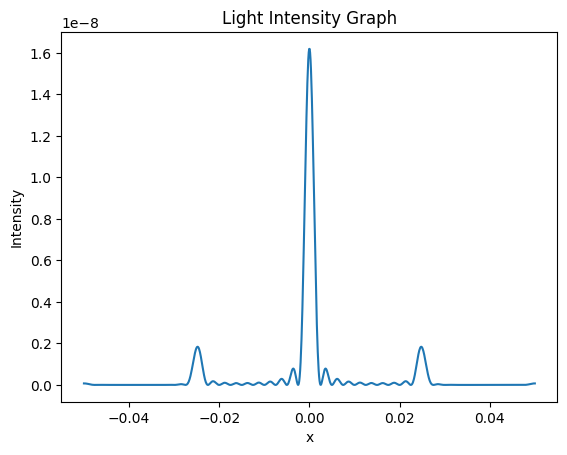

In [36]:
#가우시안 적분을 이용한 다중슬릿의 회절 세기 구하기
import numpy as np
import matplotlib.pyplot as plt
import cmath

wavelength=5e-7
d=2e-5 #주기 이자 슬릿의 간격
n=10 #(n은 슬릿의 개수)
w=d*n
focal=1
a=-w/2
b=w/2
N=1000
def q(u): #d(주기)=pi/alpha #d=2e-5일 경우 alpha=pi/(2e-5)
  alpha=(np.pi)/d
  return (np.sin(alpha*u))**2

def gaussuw(N):
  a = np.linspace(3,4*N-1,N)/(4*N+2)
  u = np.cos(np.pi*a+1/(8*N*N*np.tan(a)))

  epsilon = 1e-15
  delta = 1.0
  while delta>epsilon:
      p0 = np.ones(N,float)
      p1 = np.copy(u)
      for k in range(1,N):
          p0,p1 = p1,((2*k+1)*u*p1-k*p0)/(k+1)
      dp = (N+1)*(p0-u*p1)/(1-u*u)
      du = p1/dp
      u -= du
      delta = max(abs(du))

  w = 2*(N+1)*(N+1)/(N*N*(1-u*u)*dp*dp)

  return u,w

def gaussuwab(N,a,b):
  u,w = gaussuw(N)
  return 0.5*(b-a)*u+0.5*(b+a),0.5*(b-a)*w

def f(x,u):
  return np.sqrt(q(u))*cmath.exp((2j*np.pi*x*u)/(wavelength*focal))

def gaussian_integral(f,a,b,N,x):
  u,w=gaussuwab(N,a,b)
  s=0.0
  for i in range(N):
    s+=w[i]*f(x,u[i])
  return s
x_values=np.linspace(-0.05,0.05,1000)
I=[]
for x in x_values:
  I.append(gaussian_integral(f,a,b,N,x)) #가우시안 적분할때 x를 대입
intensity_values=np.abs(np.array(I)**2) #복소수 진폭의 절댓값 제곱으로 빛의세기(Intensity)도출
I_2d=np.tile(intensity_values,(50,1))
plt.plot(x_values,intensity_values)
plt.xlabel('x')
plt.ylabel('Intensity')
plt.title('Diffraction Intensity Graph')
plt.show()






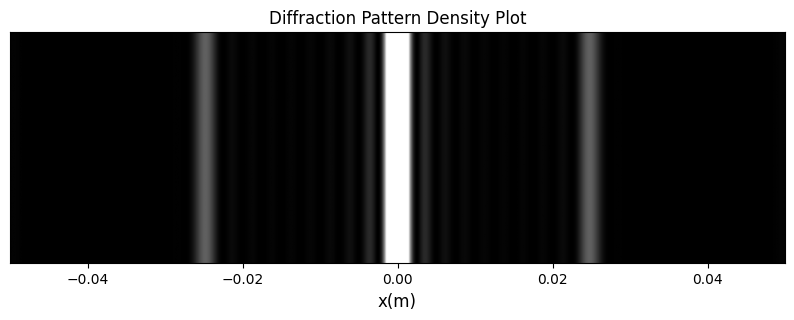

In [40]:
#밀도 띠
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10,3))
plt.imshow(
    I_2d,
    cmap='gray',
    aspect='auto',
    extent=[-0.05,0.05,0,1],
    vmax=np.max(intensity_values)*0.3
)
plt.xlabel('x(m)',fontsize=12)
plt.yticks([])
plt.title('Diffraction Pattern Density Plot')
plt.show()